# 06 — Comparison: Baseline vs Greedy vs Classical

---

### What this notebook does

Reads the result files the three solver notebooks wrote, puts them side by side, and draws the
charts. It computes **nothing** — no cleaning, no rules, no solving. If a number appears here it
was produced by `03`, `04` or `05`.

Run `02` → `03` → `04` → `05` before this one.

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)

In [2]:
import os, glob, zipfile

# Colab keeps nothing between runtimes, so the shared folder goes on Drive when we can.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK = "/content/drive/MyDrive/DOM"
except Exception:
    WORK = os.path.abspath("dom_work")

CLEAN   = f"{WORK}/clean"      # notebook 02 writes here
RESULTS = f"{WORK}/results"    # notebooks 03, 04, 05 write here
os.makedirs(CLEAN, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)
print("work folder:", WORK)

Mounted at /content/drive
work folder: /content/drive/MyDrive/DOM


In [3]:
need = ["metrics_baseline.csv", "metrics_greedy.csv", "metrics_classical.csv",
        "results_baseline.csv", "results_greedy_2A.csv", "results_classical.csv"]
missing = [f for f in need if not os.path.exists(f"{RESULTS}/{f}")]
assert not missing, f"run the earlier notebooks first — missing: {missing}"

M = pd.concat([pd.read_csv(f"{RESULTS}/metrics_baseline.csv"),
               pd.read_csv(f"{RESULTS}/metrics_greedy.csv"),
               pd.read_csv(f"{RESULTS}/metrics_classical.csv")],
              ignore_index=True)
print(f"{len(M)} scenarios loaded")

4 scenarios loaded


## 2. The headline table

Every row is scored on the same 472 focus orders, through the same `metrics()` in `dom_model`.
`objective_all` covers all 1,109 orders, so the 637 clean ones are visible too.

In [4]:
cols = ["scenario","objective_focus","objective_all","fill_rate","cases_filled",
        "orders_diverted","penalty_cost","shipping_cost","runtime_s"]
show = M[cols].copy()
for c in ["objective_focus","objective_all","penalty_cost","shipping_cost","cases_filled"]:
    show[c] = show[c].map(lambda v: f"{v:,.0f}")
show["fill_rate"] = M["fill_rate"].map(lambda v: f"{v*100:.2f}%")
show["runtime_s"] = M["runtime_s"].map(lambda v: f"{v:.2f}s")
print(show.to_string(index=False))

                        scenario objective_focus objective_all fill_rate cases_filled  orders_diverted penalty_cost shipping_cost runtime_s
 Baseline 1 · default assignment      44,365,994    75,082,940    90.47%    1,311,570                0       84,749       565,479     0.21s
      Greedy 2A · by order value      44,810,604    75,527,550    91.28%    1,323,282               41       75,259       638,165     0.40s
Greedy 2B · by shortage severity      44,786,479    75,503,425    91.26%    1,323,004               39       75,429       636,816     0.42s
        Classical · MILP (exact)      46,295,828    77,012,775    93.28%    1,352,341               66       32,333       622,880    63.72s


## 3. Against the do-nothing baseline

The first row is the reference. Everything below it is the change a planner would actually see:
fill rate bought, penalty avoided, freight spent, and whether the trade was worth it.

In [5]:
b1 = M.iloc[0]
D = pd.DataFrame({
    "scenario"          : M["scenario"],
    "Δ objective ($)"   : M["objective_focus"] - b1["objective_focus"],
    "Δ fill rate (pts)" : (M["fill_rate"] - b1["fill_rate"]) * 100,
    "Δ penalty ($)"     : M["penalty_cost"]  - b1["penalty_cost"],
    "Δ freight ($)"     : M["shipping_cost"] - b1["shipping_cost"],
    "moves"             : M["orders_diverted"],
    "runtime (s)"       : M["runtime_s"],
}).set_index("scenario").round(2)
print(D.to_string())

                                  Δ objective ($)  Δ fill rate (pts)  Δ penalty ($)  Δ freight ($)  moves  runtime (s)
scenario                                                                                                              
Baseline 1 · default assignment              0.00               0.00           0.00            0.0      0         0.21
Greedy 2A · by order value              444610.19               0.81       -9490.47        72686.0     41         0.40
Greedy 2B · by shortage severity        420484.74               0.79       -9320.11        71337.0     39         0.42
Classical · MILP (exact)               1929834.69               2.81      -52416.34        57401.0     66        63.72


### 3.1 The picture

Two panels: the money each method keeps above the baseline, and what it cost in freight to get it.

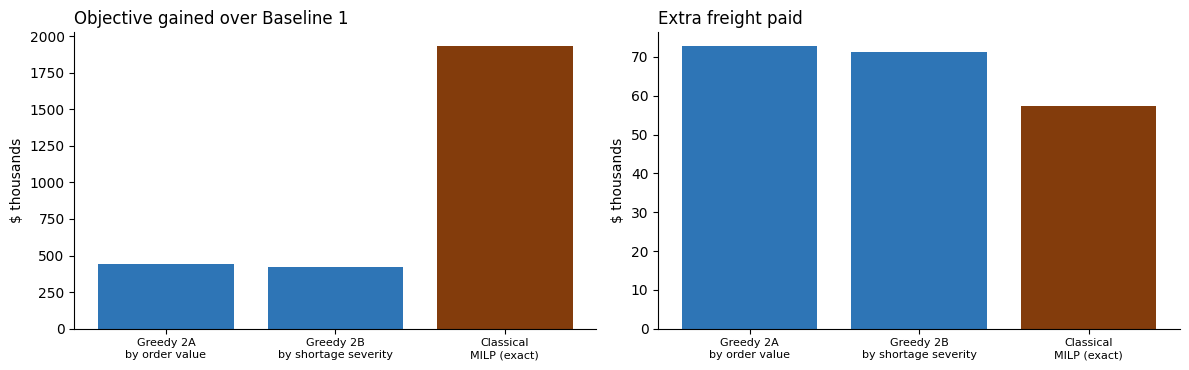

In [6]:
plot = M.iloc[1:]                                     # skip the baseline row itself
gain = plot["objective_focus"] - b1["objective_focus"]
frt  = plot["shipping_cost"]  - b1["shipping_cost"]
lab  = [s.replace(" · ", "\n") for s in plot["scenario"]]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].bar(lab, gain / 1e3, color=["#2e75b6"]*(len(plot)-1) + ["#833c0c"])
ax[0].set_title("Objective gained over Baseline 1", loc="left"); ax[0].set_ylabel("$ thousands")
ax[1].bar(lab, frt / 1e3, color=["#2e75b6"]*(len(plot)-1) + ["#833c0c"])
ax[1].set_title("Extra freight paid", loc="left"); ax[1].set_ylabel("$ thousands")
for a in ax:
    a.spines[["top","right"]].set_visible(False)
    a.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

## 4. Optimality gap

The MILP is exact, so its objective is the ceiling. The gap is how much of the reachable gain the
greedy did not find.

In [7]:
opt   = float(M.loc[M.scenario.str.startswith("Classical"), "objective_focus"].iloc[0])
gre   = M[M.scenario.str.startswith("Greedy")]
best  = gre.loc[gre.objective_focus.idxmax()]
base  = float(b1["objective_focus"])

G = pd.DataFrame([
    dict(method="Baseline 1 · default", objective=base,  gap_pct=(opt-base)/abs(opt)*100,
         share_of_reachable_gain=0.0),
    dict(method=best.scenario,          objective=best.objective_focus,
         gap_pct=(opt-best.objective_focus)/abs(opt)*100,
         share_of_reachable_gain=(best.objective_focus-base)/(opt-base)*100),
    dict(method="Classical · MILP",     objective=opt, gap_pct=0.0,
         share_of_reachable_gain=100.0),
]).round(3)
print(G.to_string(index=False))

                    method    objective  gap_pct  share_of_reachable_gain
      Baseline 1 · default 44365993.782    4.168                    0.000
Greedy 2A · by order value 44810603.973    3.208                   23.039
          Classical · MILP 46295828.477    0.000                  100.000


## 5. Where the two methods disagree

Same instance, same rules — so any order they assign differently is a search difference, not a
modelling one.

In [8]:
rb = pd.read_csv(f"{RESULTS}/results_baseline.csv").set_index("order")
rg = pd.read_csv(f"{RESULTS}/results_greedy_2A.csv").set_index("order")
rc = pd.read_csv(f"{RESULTS}/results_classical.csv").set_index("order")
focus = rb.index[rb.is_focus]

cmp = pd.DataFrame({"greedy": rg.loc[focus, "assigned_dc"],
                    "milp"  : rc.loc[focus, "assigned_dc"],
                    "default": rb.loc[focus, "assigned_dc"]})
print("focus orders            :", len(focus))
print("moved by greedy only    :", int(((cmp.greedy != cmp.default) & (cmp.milp == cmp.default)).sum()))
print("moved by MILP only      :", int(((cmp.milp != cmp.default) & (cmp.greedy == cmp.default)).sum()))
print("moved by both, same DC  :", int(((cmp.milp != cmp.default) & (cmp.greedy == cmp.milp)).sum()))
print("moved by both, other DC :", int(((cmp.milp != cmp.default) & (cmp.greedy != cmp.default)
                                        & (cmp.greedy != cmp.milp)).sum()))

focus orders            : 472
moved by greedy only    : 12
moved by MILP only      : 37
moved by both, same DC  : 26
moved by both, other DC : 3


## 6. Why orders were not moved

The greedy's reject log, which is the clearest read on which rule is actually binding.

                       count  share
reason                             
fail_5pct               1682  46.0%
sku_not_carried         1457  39.8%
no_feasible_alternate    423  11.6%
fail_100cases             37   1.0%
pgi_out_of_horizon        24   0.7%
no_dock                   17   0.5%
no_pick_capacity          11   0.3%
no_objective_gain          8   0.2%


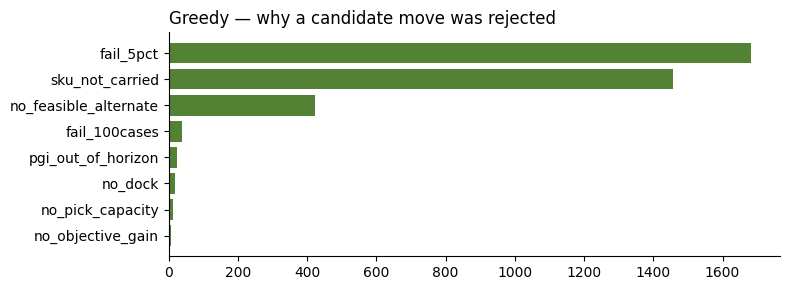

In [9]:
log = pd.read_csv(f"{RESULTS}/greedy_rejection_log.csv")
rej = log.reason.value_counts().rename("count").to_frame()
rej["share"] = (rej["count"] / rej["count"].sum()).map(lambda v: f"{v*100:.1f}%")
print(rej.to_string())

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(rej.index[::-1], rej["count"][::-1], color="#548235")
ax.set_title("Greedy — why a candidate move was rejected", loc="left")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 7. Planner view

The best solution, in business language, sorted by money gained. This is the one-page deliverable:
which order moves, from where to where, what it buys and what it costs.

In [10]:
bestfile = "results_classical.csv" if opt >= best.objective_focus else "results_greedy_2A.csv"
R = pd.read_csv(f"{RESULTS}/{bestfile}").set_index("order")
mv = R[R.moved & R.is_focus]

pv = pd.DataFrame({
    "order"        : mv.index,
    "from"         : mv.default_dc.values,
    "to"           : mv.assigned_dc.values,
    "fill"         : [f"{a*100:.0f}% → {b*100:.0f}%"
                      for a, b in zip(rb.loc[mv.index, "cof"], mv.cof)],
    "extra cases"  : (mv.filled_cases.values - rb.loc[mv.index, "filled_cases"].values).round(0),
    "penalty saved": (rb.loc[mv.index, "penalty"].values - mv.penalty.values).round(0),
    "extra freight": (mv.shipping.values - rb.loc[mv.index, "shipping"].values).round(0),
    "net gain"     : (mv.objective.values - rb.loc[mv.index, "objective"].values).round(0),
}).sort_values("net gain", ascending=False)

print(f"source: {bestfile}   |   orders recommended for reassignment: {len(pv)}")
print(pv.head(15).to_string(index=False))
pv.to_csv(f"{RESULTS}/planner_view.csv", index=False)

source: results_classical.csv   |   orders recommended for reassignment: 66
     order  from   to       fill  extra cases  penalty saved  extra freight  net gain
5484926947  5420 5490  27% → 67%        882.0            0.0         2883.0   76497.0
5485532552  5490 5410 86% → 100%        356.0         1879.0         1064.0   46501.0
5485069375  5490 5620 89% → 100%        321.0         1713.0         2386.0   42147.0
5484650344  5620 5420  10% → 34%        732.0            0.0        -4892.0   37875.0
5485525163  5385 5641  91% → 99%        212.0         1141.0          -46.0   27455.0
5485613216  5385 5641  68% → 97%        303.0         1031.0           49.0   26758.0
5485496838  5385 5420  92% → 98%        142.0         1205.0          113.0   25390.0
5485108289  5641 5620  84% → 99%        497.0            0.0         3660.0   25374.0
5483875303  5620 5410 62% → 100%       1020.0            0.0         3114.0   21807.0
8029881894  5420 5490  77% → 94%        544.0          896.0    

### 7.1 Where the volume goes

In [11]:
print(pv.groupby("to")[["extra cases","penalty saved","extra freight","net gain"]]
        .agg(["count","sum"]).round(0).to_string())

     extra cases         penalty saved         extra freight          net gain          
           count     sum         count     sum         count      sum    count       sum
to                                                                                      
5385           4  1146.0             4   336.0             4   4483.0        4   27143.0
5410          13  3793.0            13  3772.0            13   1950.0       13  133009.0
5420          11  3251.0            11  4401.0            11   4681.0       11  142980.0
5490          22  5467.0            22  3147.0            22  24656.0       22  208059.0
5620           7  2187.0             7  2412.0             7  13890.0        7   92866.0
5641           4   929.0             4  2694.0             4   3847.0        4   65859.0
5773           5   923.0             5     0.0             5   3894.0        5   44498.0


## 8. Against the 2024 POC

Nestlé's own run recommended very few diverts. Both of our methods recommend more, and the reason
is a missing file rather than a better search: with no demand forecast in the pack, nothing
reserves stock at the receiving DC, so a divert looks cheaper to us than it did to them. The
greedy sensitivity in `04` that holds back 50% of stock elsewhere is the closest available proxy.

In [12]:
poc_path = f"{CLEAN}/poc_reference.csv"
if os.path.exists(poc_path):
    poc = pd.read_csv(poc_path)
    print("POC diverts        :", int((poc.IsDivert != "Default").sum()))
else:
    print("poc_reference.csv not found — re-run 02_data_cleaning")

print("greedy 2A diverts  :", int(best.orders_diverted))
print("MILP diverts       :", int(M.loc[M.scenario.str.startswith("Classical"),
                                        "orders_diverted"].iloc[0]))

sens_path = f"{RESULTS}/greedy_sensitivity.csv"
if os.path.exists(sens_path):
    S = pd.read_csv(sens_path)
    print("\ngreedy under a 50% stock reserve elsewhere:")
    print(S[["scenario","orders_diverted","fill_rate","objective_focus"]].to_string(index=False))

POC diverts        : 3
greedy 2A diverts  : 41
MILP diverts       : 66

greedy under a 50% stock reserve elsewhere:
                          scenario  orders_diverted  fill_rate  objective_focus
gate as written (5pts + 100 cases)               41      91.28     4.481060e+07
                  no 100-case rule               49      91.31     4.482856e+07
            stricter gate (10 pts)               29      91.11     4.470020e+07
     hold back 50% stock elsewhere               35      91.05     4.462680e+07


## 9. Save the comparison

In [13]:
M.to_csv(f"{RESULTS}/comparison_all.csv", index=False)
D.reset_index().to_csv(f"{RESULTS}/comparison_vs_baseline.csv", index=False)
G.to_csv(f"{RESULTS}/optimality_gap.csv", index=False)
print("wrote comparison_all.csv, comparison_vs_baseline.csv, optimality_gap.csv, planner_view.csv")

wrote comparison_all.csv, comparison_vs_baseline.csv, optimality_gap.csv, planner_view.csv


## 10. Reading the result

* **Both search methods beat doing nothing**, and they do it the same way: buy fill rate, save
  penalty, pay freight. The objective is what decides the trade, and it is positive for both.
* **The percentage gain looks small because the denominator is large.** Most of the 472 focus
  orders were only slightly short. Against the *reachable* gain — the distance between the
  baseline and the proven optimum — the greedy's shortfall is a much more meaningful number, and
  that is the one section 4 reports.
* **The greedy is fast and gets most of the way.** For a planner refreshing recommendations
  through the day that may be the right tool. The MILP is the right tool for setting a target,
  because it is the only one of the three that can say how much is left.
* **Both are limited by the same missing data**, not by the search: no forecast, no throughput
  ceiling, no holiday calendar. Those are in the assumptions table in `02`, and they bound every
  number on this page.